# OMPL/IK Log Analysis Notebook

Notebook ini menganalisis semua summary log dan event log robot dari folder `logs/`, ditambah data refactor di `docs/refactor_metrics.csv`.

Output utamanya adalah dataframe untuk tracking, error, IK, OMPL, trajectory execution, dan insight visualisasi per progress refactor.

In [14]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 140)
plt.style.use('seaborn-v0_8-whitegrid')

cwd = Path.cwd()
ROOT = cwd if (cwd / 'logs').exists() else cwd.parent
LOG_DIR = ROOT / 'logs'
DOC_DIR = ROOT / 'docs'
OUT_DIR = DOC_DIR / 'notebook_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT    =', ROOT)
print('LOG_DIR =', LOG_DIR)
print('OUT_DIR =', OUT_DIR)

ROOT    = c:\projek\MVP-CTAMP-ROBOT
LOG_DIR = c:\projek\MVP-CTAMP-ROBOT\logs
OUT_DIR = c:\projek\MVP-CTAMP-ROBOT\docs\notebook_outputs


## 1. Load Semua Log

Ada dua tipe CSV:

- Summary CSV: satu baris per run, berisi `success`, `objects_moved`, `objects_total`, dan `failed_json`.
- Event CSV: banyak baris per run, berisi stage-level tracing seperti `IK_CANDIDATE`, `OMPL_PLAN`, `TRAJECTORY_EXEC`, `CHECK_PICK`, dan `CHECK_PLACE`.

In [15]:
RUN_RE = re.compile(r'^(align_[a-z]+)_(.+)_(\d{8}_\d{6})(?:_events)?\.csv$')

def parse_meta(path: Path) -> dict:
    m = RUN_RE.match(path.name)
    if not m:
        return {'run_id': path.stem, 'task': None, 'scene': None, 'run_ts': pd.NaT, 'is_event': path.name.endswith('_events.csv')}
    task, scene, ts = m.groups()
    return {
        'run_id': f'{task}_{scene}_{ts}',
        'task': task,
        'scene': scene,
        'run_ts': pd.to_datetime(ts, format='%Y%m%d_%H%M%S', errors='coerce'),
        'is_event': path.name.endswith('_events.csv'),
    }

def read_summary_logs() -> pd.DataFrame:
    rows = []
    for path in sorted(LOG_DIR.glob('*.csv')):
        if path.name.endswith('_events.csv'):
            continue
        meta = parse_meta(path)
        df = pd.read_csv(path)
        for _, row in df.iterrows():
            item = row.to_dict()
            item.update(meta)
            item['file'] = path.name
            rows.append(item)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out['objects_moved'] = pd.to_numeric(out.get('objects_moved'), errors='coerce')
    out['objects_total'] = pd.to_numeric(out.get('objects_total'), errors='coerce')
    out['object_success_rate'] = out['objects_moved'] / out['objects_total']
    out['success_bool'] = out.get('success').astype(str).str.lower().eq('true')
    out['obstacle_mode'] = np.where(out['scene'].astype(str).str.endswith('_no_obs'), 'no_obs', np.where(out['scene'].astype(str).str.endswith('_obs'), 'obs', 'unknown'))
    return out.sort_values('run_ts').reset_index(drop=True)

def read_event_logs() -> pd.DataFrame:
    frames = []
    for path in sorted(LOG_DIR.glob('*_events.csv')):
        meta = parse_meta(path)
        df = pd.read_csv(path)
        for key, value in meta.items():
            df[key] = value
        df['file'] = path.name
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True, sort=False)
    out['timestamp_dt'] = pd.to_datetime(out.get('timestamp'), errors='coerce')
    numeric_cols = ['event_id', 'attempt', 'candidate_id', 'seed_id', 'waypoints', 'duration_ms', 'grip', 'object_z', 'finger_pos', 'q_error_norm', 'pos_err', 'ori_err', 'iterations', 'distance_to_target', 'contact_count', 'penetration', 'obstacle_distance']
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.sort_values(['run_ts', 'event_id']).reset_index(drop=True)

summary_df = read_summary_logs()
event_df = read_event_logs()
refactor_df = pd.read_csv(DOC_DIR / 'refactor_metrics.csv') if (DOC_DIR / 'refactor_metrics.csv').exists() else pd.DataFrame()

summary_df.head(), event_df.head(), refactor_df.head()

(           task         scene  success  objects_moved  objects_total  \
 0  align_tabung  group_no_obs    False              2              4   
 1  align_tabung  group_no_obs    False              3              4   
 2   align_cubes  group_no_obs    False              3              4   
 3   align_cubes  group_no_obs    False              3              4   
 4   align_cubes  group_no_obs    False              0              4   
 
    failed_count  \
 0             2   
 1             1   
 2             1   
 3             1   
 4             4   
 
                                                                                                                                    failed_json  \
 0  [{"object_id": "circle3", "stage": "pick", "z": 0.838, "attempts": 3}, {"object_id": "circle4", "stage": "pick", "z": 0.838, "attempts":...   
 1                                                                       [{"object_id": "circle4", "stage": "pick", "z": 0.838, "attempts": 3}] 

In [16]:
print('summary_df:', summary_df.shape)
print('event_df  :', event_df.shape)
print('refactor_df:', refactor_df.shape)
display(summary_df[['file', 'task', 'scene', 'success_bool', 'objects_moved', 'objects_total', 'object_success_rate']].tail(12))

summary_df: (14, 24)
event_df  : (14495, 51)
refactor_df: (9, 10)


,file,task,scene,success_bool,objects_moved,objects_total,object_success_rate
2,align_cubes_group_no_obs_20260526_232400.csv,align_cubes,group_no_obs,False,3,4,0.75
3,align_cubes_group_no_obs_20260527_184904.csv,align_cubes,group_no_obs,False,3,4,0.75
4,align_cubes_group_no_obs_20260527_201418.csv,align_cubes,group_no_obs,False,0,4,0.00
5,align_cubes_group_no_obs_20260527_203236.csv,align_cubes,group_no_obs,False,2,4,0.50
6,align_cubes_group_no_obs_20260527_203523.csv,align_cubes,group_no_obs,False,3,4,0.75
7,align_cubes_group_no_obs_20260527_203818.csv,align_cubes,group_no_obs,False,3,4,0.75
8,align_cubes_group_no_obs_20260527_204059.csv,align_cubes,group_no_obs,True,4,4,1.00
9,align_cubes_group_no_obs_20260527_204557.csv,align_cubes,group_no_obs,True,4,4,1.00
10,align_tabung_group_no_obs_20260527_204857.csv,align_tabung,group_no_obs,True,4,4,1.00
11,align_tabung_group_obs_20260527_205059.csv,align_tabung,group_obs,False,1,4,0.25


## 2. Dataframe Turunan untuk Analisis

Dataframe berikut dipakai untuk visualisasi:

- `tracking_df`: alur stage eksekusi per run/object.
- `error_df`: semua row yang memiliki `failure_reason`, `FAILED`, `ERROR`, `UNAVAILABLE`, atau `REJECT`.
- `ik_df`: semua row IK candidate dan IK solve.
- `ompl_df`: semua row OMPL plan/attempt.
- `trajectory_df`: semua row eksekusi trajectory.
- `per_log_analysis_df`: ringkasan satu baris per event log.

In [17]:
tracking_stages = [
    'TASK_CONTEXT', 'TASK_ROUND', 'OBJECT_PRECHECK',
    'PICK', 'PICK_PROFILE', 'PICK_PRECHECK', 'PICK_TARGETS',
    'MOVE_POSE', 'IK_SOLVE', 'IK_CANDIDATE',
    'OMPL_PLAN', 'OMPL_PLAN_ATTEMPT', 'TRAJECTORY_EXEC', 'TRAJECTORY_WAYPOINT',
    'CHECK_PICK', 'PLACE', 'PLACE_PRECHECK', 'PLACE_TARGETS', 'CHECK_PLACE',
    'COLLISION_CHECK', 'DROP', 'RECOVERY'
]

tracking_df = event_df[event_df['stage'].isin(tracking_stages)].copy()
error_df = event_df[
    event_df.get('failure_reason').fillna('').ne('') |
    event_df.get('status').isin(['FAILED', 'ERROR', 'UNAVAILABLE', 'REJECT'])
].copy()
ik_df = event_df[event_df['stage'].isin(['IK_CANDIDATE', 'IK_SOLVE'])].copy()
ompl_df = event_df[event_df['stage'].isin(['OMPL_PLAN', 'OMPL_PLAN_ATTEMPT'])].copy()
trajectory_df = event_df[event_df['stage'].isin(['TRAJECTORY_EXEC', 'TRAJECTORY_WAYPOINT'])].copy()

def compact_counts(series, n=8):
    counts = series.dropna().astype(str)
    counts = counts[counts.ne('')].value_counts().head(n)
    return '; '.join(f'{k}: {v}' for k, v in counts.items())

per_log_rows = []
for file, group in event_df.groupby('file', sort=True):
    per_log_rows.append({
        'file': file,
        'run_id': group['run_id'].iloc[0],
        'task': group['task'].iloc[0],
        'scene': group['scene'].iloc[0],
        'rows': len(group),
        'start': group['timestamp_dt'].min(),
        'end': group['timestamp_dt'].max(),
        'ik_ok': int(((group['stage'] == 'IK_CANDIDATE') & (group['status'] == 'OK')).sum()),
        'ik_reject': int(((group['stage'] == 'IK_CANDIDATE') & (group['status'] == 'REJECT')).sum()),
        'ompl_ok': int(((group['stage'] == 'OMPL_PLAN') & (group['status'] == 'OK')).sum()),
        'ompl_failed': int(((group['stage'] == 'OMPL_PLAN') & group['status'].isin(['FAILED', 'ERROR', 'UNAVAILABLE'])).sum()),
        'trajectory_ok': int(((group['stage'] == 'TRAJECTORY_EXEC') & (group['status'] == 'OK')).sum()),
        'trajectory_failed': int(((group['stage'] == 'TRAJECTORY_EXEC') & (group['status'] == 'FAILED')).sum()),
        'top_failures': compact_counts(group['failure_reason']),
        'top_collision_pairs': compact_counts(group['collision_pair']),
    })

per_log_analysis_df = pd.DataFrame(per_log_rows).sort_values(['task', 'scene', 'start']).reset_index(drop=True)

display(per_log_analysis_df)

,file,run_id,task,scene,rows,start,end,ik_ok,ik_reject,ompl_ok,ompl_failed,trajectory_ok,trajectory_failed,top_failures,top_collision_pairs
0,align_cubes_group_no_obs_20260526_232140_events.csv,align_cubes_group_no_obs_20260526_232140,align_cubes,group_no_obs,607,2026-05-26 23:21:45.911,2026-05-26 23:23:59.393,51,56,30,0,30,0,robot-env contact: table/1 <-> left_finger/80: 14; robot-env contact: cube4/8 <-> hand/77: 13; object_not_lifted_after_pick: 3; pick_fai...,
1,align_cubes_group_no_obs_20260527_184528_events.csv,align_cubes_group_no_obs_20260527_184528,align_cubes,group_no_obs,607,2026-05-27 18:45:38.713,2026-05-27 18:49:03.885,51,56,30,0,30,0,robot-env contact: table/1 <-> left_finger/80: 14; robot-env contact: cube4/8 <-> hand/77: 13; object_not_lifted_after_pick: 3; pick_fai...,
2,align_cubes_group_no_obs_20260527_194118_events.csv,align_cubes_group_no_obs_20260527_194118,align_cubes,group_no_obs,752,2026-05-27 19:41:32.750,2026-05-27 19:44:35.287,315,177,17,0,16,0,ik_error_above_limit: 126; ik_goal_collision_invalid: 51; object_not_lifted: 3; object_not_lifted_after_pick: 3; pick_failed_try_other_c...,
3,align_cubes_group_no_obs_20260527_201219_events.csv,align_cubes_group_no_obs_20260527_201219,align_cubes,group_no_obs,736,2026-05-27 20:12:26.899,2026-05-27 20:14:17.301,0,468,12,0,12,0,ik_error_above_limit: 480; move_pregrasp_failed: 12; object_not_lifted_after_pick: 12; pick_failed_try_other_candidate: 8,
4,align_cubes_group_no_obs_20260527_202105_events.csv,align_cubes_group_no_obs_20260527_202105,align_cubes,group_no_obs,2356,2026-05-27 20:21:13.545,2026-05-27 20:26:37.171,255,865,32,0,22,10,pinocchio_fk_validation_failed: 724; ik_error_above_limit: 670; ik_goal_collision_invalid: 194; robot-env contact: table/1 <-> left_fing...,"[""table"", ""left_finger""]: 15; [""cube1"", ""hand""]: 9"
5,align_cubes_group_no_obs_20260527_202959_events.csv,align_cubes_group_no_obs_20260527_202959,align_cubes,group_no_obs,1276,2026-05-27 20:30:10.572,2026-05-27 20:32:36.631,128,375,32,0,32,0,pinocchio_fk_validation_failed: 252; ik_error_above_limit: 196; ik_goal_collision_invalid: 176; ik_orientation_error_above_limit: 7; obj...,
6,align_cubes_group_no_obs_20260527_203344_events.csv,align_cubes_group_no_obs_20260527_203344,align_cubes,group_no_obs,893,2026-05-27 20:33:52.278,2026-05-27 20:35:23.600,133,132,30,0,28,2,pinocchio_fk_validation_failed: 147; ik_error_above_limit: 111; ik_goal_collision_invalid: 18; robot-env contact: table/1 <-> left_finge...,"[""table"", ""left_finger""]: 16"
7,align_cubes_group_no_obs_20260527_203658_events.csv,align_cubes_group_no_obs_20260527_203658,align_cubes,group_no_obs,897,2026-05-27 20:37:03.768,2026-05-27 20:38:18.609,144,37,41,0,27,14,robot-env contact: table/1 <-> right_finger/88: 91; pinocchio_fk_validation_failed: 73; ik_error_above_limit: 36; ompl_or_execution_fail...,"[""table"", ""right_finger""]: 91; [""cube4"", ""hand""]: 7"
8,align_cubes_group_no_obs_20260527_203918_events.csv,align_cubes_group_no_obs_20260527_203918,align_cubes,group_no_obs,844,2026-05-27 20:39:24.556,2026-05-27 20:40:59.792,142,121,28,0,28,0,pinocchio_fk_validation_failed: 151; ik_error_above_limit: 120; ik_orientation_error_above_limit: 1,
9,align_cubes_group_no_obs_20260527_204324_events.csv,align_cubes_group_no_obs_20260527_204324,align_cubes,group_no_obs,844,2026-05-27 20:43:30.379,2026-05-27 20:45:57.024,142,121,28,0,28,0,pinocchio_fk_validation_failed: 151; ik_error_above_limit: 120; ik_orientation_error_above_limit: 1,


In [18]:
exports = {
    'log_summary_dataframe.csv': summary_df,
    'log_tracking_dataframe.csv': tracking_df,
    'log_error_dataframe.csv': error_df,
    'log_ik_dataframe.csv': ik_df,
    'log_ompl_dataframe.csv': ompl_df,
    'log_trajectory_dataframe.csv': trajectory_df,
    'log_per_file_analysis.csv': per_log_analysis_df,
}
for name, df in exports.items():
    df.to_csv(OUT_DIR / name, index=False)
print('exported:', sorted(exports))

exported: ['log_error_dataframe.csv', 'log_ik_dataframe.csv', 'log_ompl_dataframe.csv', 'log_per_file_analysis.csv', 'log_summary_dataframe.csv', 'log_tracking_dataframe.csv', 'log_trajectory_dataframe.csv']


## 3. Visualisasi Success Rate per Run

Insight: run lama memperlihatkan cubes dan tabung belum stabil. Refactor 1 sempat turun karena bug frame Pinocchio. Refactor 2 menunjukkan final no-obstacle sudah stabil di 100% untuk group dan ungroup.

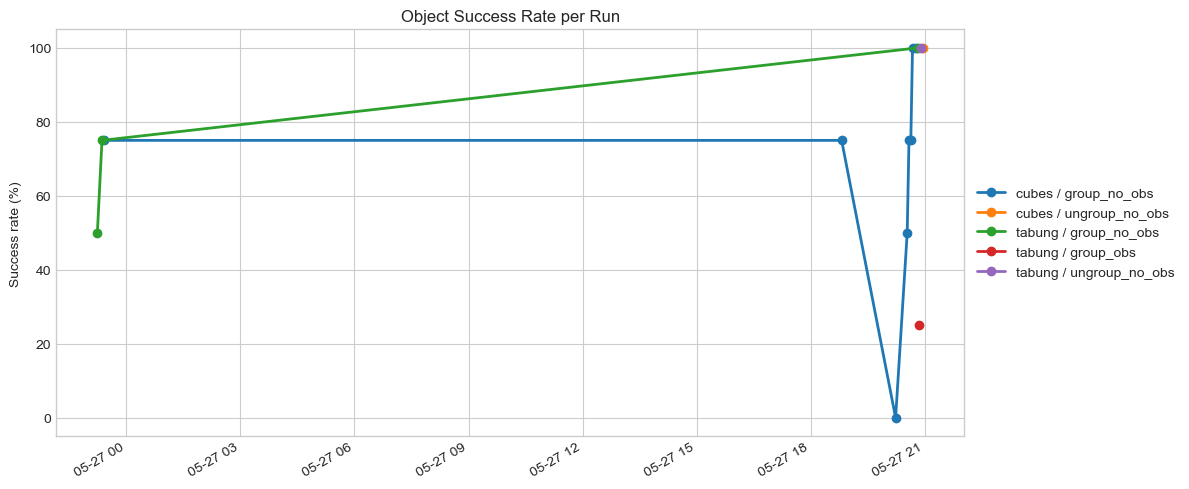

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = summary_df.sort_values('run_ts').copy()
plot_df['label'] = plot_df['task'].str.replace('align_', '', regex=False) + ' / ' + plot_df['scene']
for label, g in plot_df.groupby('label'):
    ax.plot(g['run_ts'], g['object_success_rate'] * 100, marker='o', linewidth=2, label=label)
ax.set_title('Object Success Rate per Run')
ax.set_ylabel('Success rate (%)')
ax.set_ylim(-5, 105)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT_DIR / 'success_rate_per_run.png', dpi=160)
plt.show()

## 4. Visualisasi Progress Refactor

Insight: Refactor 1 adalah fase observability dan diagnosis. Angka success rate tidak selalu naik di fase ini, tetapi failure reason menjadi spesifik sehingga Refactor 2 bisa diarahkan ke frame conversion, FK validation, ignore-list grasp, dan ranking grasp.

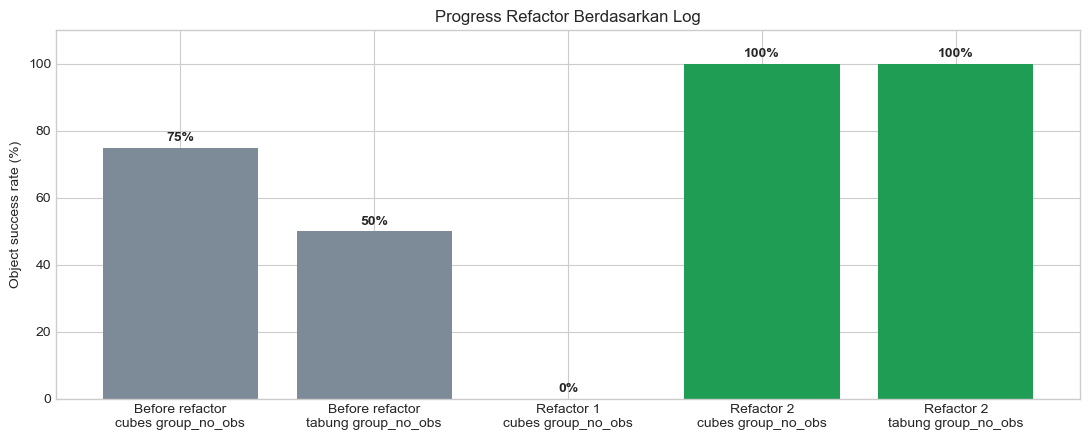

,milestone,scope,moved,total,rate,note
0,Before refactor,cubes group_no_obs,3,4,0.75,cube4 gagal pick
1,Before refactor,tabung group_no_obs,2,4,0.50,circle3/circle4 gagal pick
2,Refactor 1,cubes group_no_obs,0,4,0.00,Pinocchio frame mismatch
3,Refactor 2,cubes group_no_obs,4,4,1.00,Pinocchio base-frame + grasp fix
4,Refactor 2,tabung group_no_obs,4,4,1.00,candidate retry + object guards


In [20]:
progress_df = refactor_df[refactor_df['section'].eq('progress')].copy()
if not progress_df.empty:
    progress_df['label'] = progress_df['milestone'] + '\n' + progress_df['scope']
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(progress_df['label'], progress_df['rate'] * 100, color=['#7d8b99', '#7d8b99', '#5b8def', '#1f9d55', '#1f9d55'])
    ax.set_title('Progress Refactor Berdasarkan Log')
    ax.set_ylabel('Object success rate (%)')
    ax.set_ylim(0, 110)
    for idx, row in progress_df.iterrows():
        ax.text(idx, row['rate'] * 100 + 2, f"{int(row['rate'] * 100)}%", ha='center', fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'refactor_progress_from_dataframe.png', dpi=160)
    plt.show()
display(progress_df[['milestone', 'scope', 'moved', 'total', 'rate', 'note']])

## 5. Visualisasi Failure Reason

Insight: failure terbesar sebelum final bukan OMPL no-path. Pola dominan adalah `ik_error_above_limit`, `pinocchio_fk_validation_failed`, `ik_goal_collision_invalid`, dan object-level feedback seperti `object_not_lifted_after_pick`. Ini menunjukkan root cause berada pada IK candidate quality, frame validation, dan grasp geometry.

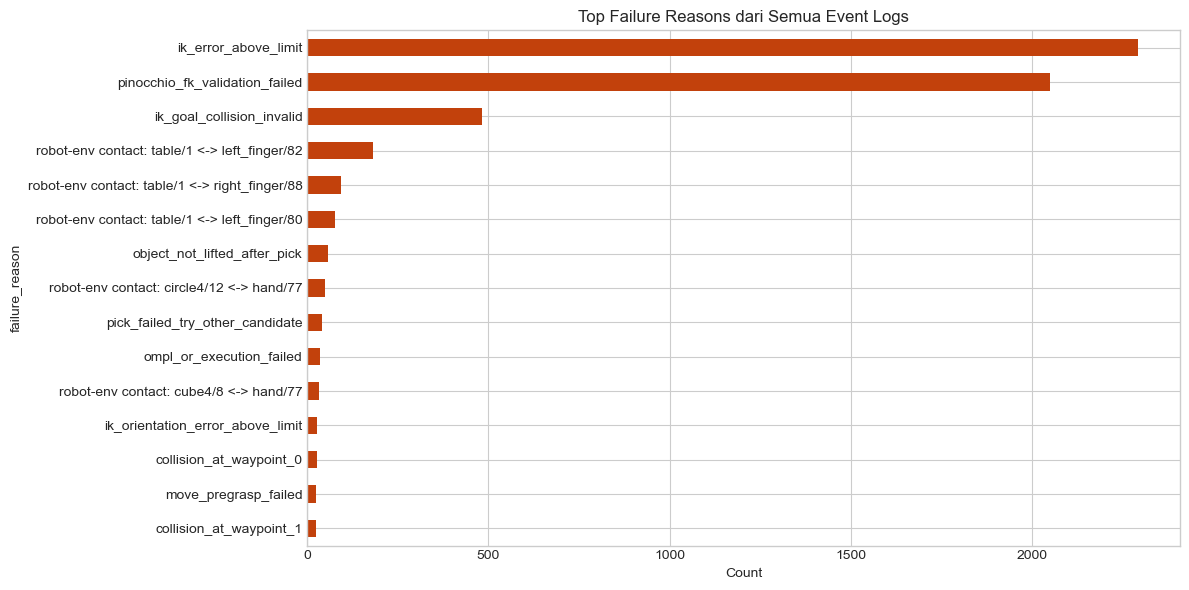

,failure_reason,count
0,ik_error_above_limit,2295
1,pinocchio_fk_validation_failed,2051
2,ik_goal_collision_invalid,481
3,robot-env contact: table/1 <-> left_finger/82,182
4,robot-env contact: table/1 <-> right_finger/88,93
5,robot-env contact: table/1 <-> left_finger/80,75
6,object_not_lifted_after_pick,58
7,robot-env contact: circle4/12 <-> hand/77,48
8,pick_failed_try_other_candidate,41
9,ompl_or_execution_failed,34


In [21]:
failure_counts = error_df['failure_reason'].dropna().astype(str)
failure_counts = failure_counts[failure_counts.ne('')].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
failure_counts.sort_values().plot(kind='barh', ax=ax, color='#c2410c')
ax.set_title('Top Failure Reasons dari Semua Event Logs')
ax.set_xlabel('Count')
fig.tight_layout()
fig.savefig(OUT_DIR / 'top_failure_reasons.png', dpi=160)
plt.show()

display(failure_counts.rename_axis('failure_reason').reset_index(name='count'))

## 6. Visualisasi IK Backend dan Candidate Outcome

Insight: setelah Pinocchio aktif, backend `pinocchio` dan fallback `mujoco_dls` sama-sama muncul. Banyak `BACKEND_FALLBACK` adalah sinyal sehat: Pinocchio dicoba dulu, lalu MuJoCo FK menjaga agar goal yang tidak konsisten tidak masuk OMPL.

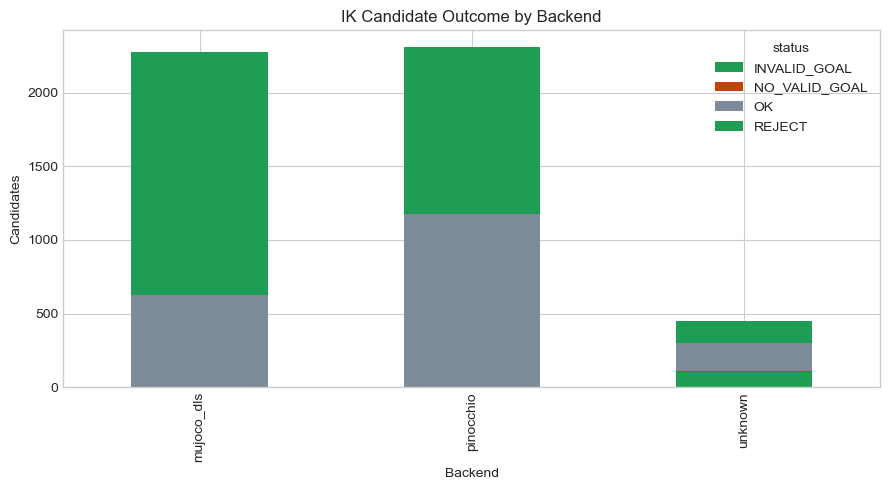

status,INVALID_GOAL,NO_VALID_GOAL,OK,REJECT
backend,,,,
mujoco_dls,0,0,628,1646
pinocchio,0,0,1175,1132
unknown,104,4,195,144


,fallback_reason,count
0,pinocchio_fk_validation_failed,2051


In [22]:
ik_candidates = ik_df[ik_df['stage'].eq('IK_CANDIDATE')].copy()
ik_backend_status = pd.crosstab(ik_candidates['backend'].fillna('unknown'), ik_candidates['status'].fillna('unknown'))

fig, ax = plt.subplots(figsize=(9, 5))
ik_backend_status.plot(kind='bar', stacked=True, ax=ax, color=['#1f9d55', '#c2410c', '#7d8b99'])
ax.set_title('IK Candidate Outcome by Backend')
ax.set_xlabel('Backend')
ax.set_ylabel('Candidates')
ax.legend(title='status')
fig.tight_layout()
fig.savefig(OUT_DIR / 'ik_candidate_outcome_by_backend.png', dpi=160)
plt.show()

fallback_df = ik_df[(ik_df['stage'].eq('IK_SOLVE')) & (ik_df['status'].eq('BACKEND_FALLBACK'))]
display(ik_backend_status)
display(fallback_df['failure_reason'].value_counts().rename_axis('fallback_reason').reset_index(name='count').head(10))

## 7. Visualisasi OMPL Plan

Insight: OMPL mayoritas berhasil saat goal sudah valid. Pada log yang berhasil, `OMPL_PLAN OK` tinggi dan `ompl_result=success`. Ini menguatkan bahwa bottleneck utama bukan planner no-path, melainkan validasi IK/grasp sebelum OMPL atau collision saat trajectory execution.

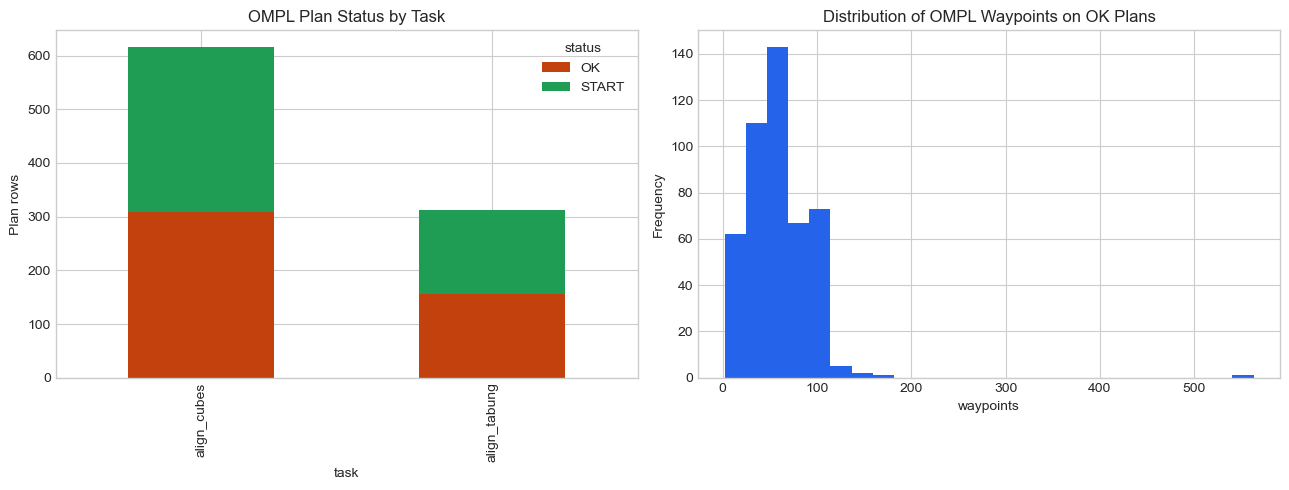

status,OK,START
task,,
align_cubes,308,308
align_tabung,156,156


,file,phase,planner,waypoints,duration_ms,ompl_result
13854,align_cubes_ungroup_no_obs_20260527_205514_events.csv,pick(cube1) grasp,RRTConnect,44.0,101.0,success
13874,align_cubes_ungroup_no_obs_20260527_205514_events.csv,pick(cube1) lift,RRTConnect,45.0,79.0,success
13897,align_cubes_ungroup_no_obs_20260527_205514_events.csv,"place(0.165, -0.125) preplace",RRTConnect,68.0,120.0,success
13915,align_cubes_ungroup_no_obs_20260527_205514_events.csv,"place(0.165, -0.125) release",RRTConnect,34.0,71.0,success
13939,align_cubes_ungroup_no_obs_20260527_205514_events.csv,"place(0.165, -0.125) retreat",RRTConnect,47.0,58.0,success
13951,align_cubes_ungroup_no_obs_20260527_205514_events.csv,"transit after place(0.165, -0.125)",RRTConnect,57.0,89.0,success
13982,align_cubes_ungroup_no_obs_20260527_205514_events.csv,pick(cube4) pregrasp,RRTConnect,81.0,88.0,success
14005,align_cubes_ungroup_no_obs_20260527_205514_events.csv,pick(cube4) grasp,RRTConnect,43.0,64.0,success
14032,align_cubes_ungroup_no_obs_20260527_205514_events.csv,pick(cube4) lift,RRTConnect,38.0,99.0,success
14057,align_cubes_ungroup_no_obs_20260527_205514_events.csv,"place(0.275, -0.125) preplace",RRTConnect,66.0,85.0,success


In [23]:
ompl_plan = ompl_df[ompl_df['stage'].eq('OMPL_PLAN')].copy()
ompl_status = pd.crosstab(ompl_plan['task'], ompl_plan['status'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ompl_status.plot(kind='bar', stacked=True, ax=axes[0], color=['#c2410c', '#1f9d55', '#7d8b99'])
axes[0].set_title('OMPL Plan Status by Task')
axes[0].set_ylabel('Plan rows')

ompl_ok = ompl_plan[ompl_plan['status'].eq('OK')]
ompl_ok['waypoints'].dropna().plot(kind='hist', bins=25, ax=axes[1], color='#2563eb')
axes[1].set_title('Distribution of OMPL Waypoints on OK Plans')
axes[1].set_xlabel('waypoints')
fig.tight_layout()
fig.savefig(OUT_DIR / 'ompl_plan_status_and_waypoints.png', dpi=160)
plt.show()

display(ompl_status)
display(ompl_ok[['file', 'phase', 'planner', 'waypoints', 'duration_ms', 'ompl_result']].tail(20))

## 8. Visualisasi Trajectory dan Collision

Insight: saat path sudah ditemukan, kegagalan dapat tetap muncul di eksekusi live MuJoCo. Contact seperti `table <-> finger` atau `object <-> hand` menunjukkan masalah grasp height/ranking, bukan OMPL availability.

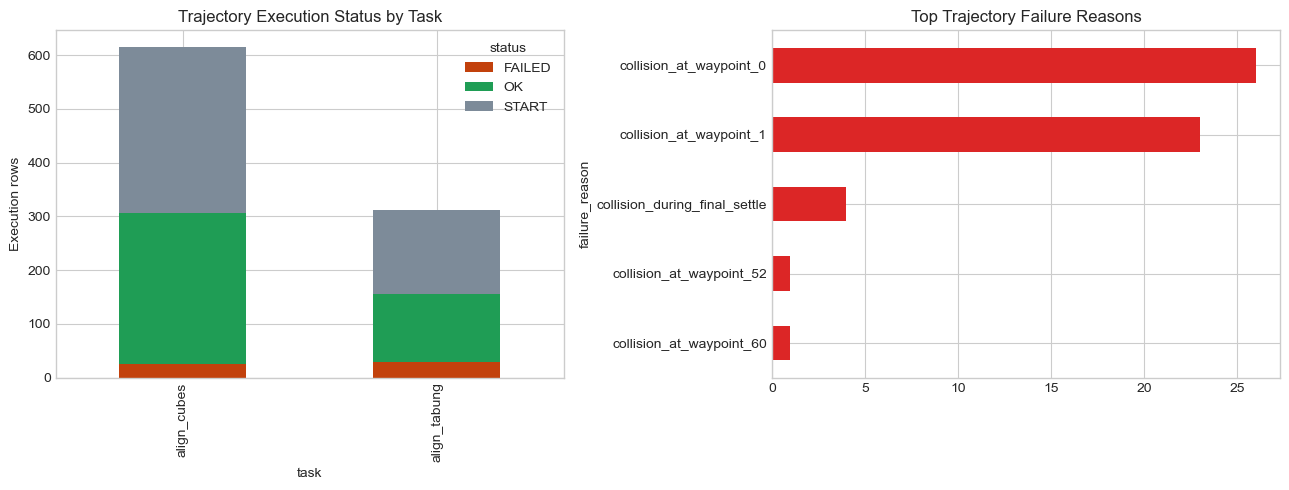

status,FAILED,OK,START
task,,,
align_cubes,26,281,308
align_tabung,29,127,156


,file,phase,failure_reason,collision_pair,penetration,waypoints,duration_ms
8304,align_cubes_group_no_obs_20260527_203344_events.csv,NaN,collision_during_final_settle,NaN,NaN,30.0,585.0
8331,align_cubes_group_no_obs_20260527_203344_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,103.0,520.0
8931,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_60,NaN,NaN,61.0,748.0
8954,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,3.0,566.0
8976,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,19.0,483.0
8998,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,22.0,472.0
9020,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,18.0,461.0
9042,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,16.0,462.0
9069,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,150.0,506.0
9094,align_cubes_group_no_obs_20260527_203658_events.csv,NaN,collision_at_waypoint_1,NaN,NaN,60.0,75.0


In [24]:
traj_exec = trajectory_df[trajectory_df['stage'].eq('TRAJECTORY_EXEC')].copy()
traj_status = pd.crosstab(traj_exec['task'], traj_exec['status'])
traj_fail = traj_exec[traj_exec['status'].eq('FAILED')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
traj_status.plot(kind='bar', stacked=True, ax=axes[0], color=['#c2410c', '#1f9d55', '#7d8b99'])
axes[0].set_title('Trajectory Execution Status by Task')
axes[0].set_ylabel('Execution rows')

collision_counts = traj_fail['failure_reason'].dropna().astype(str)
collision_counts = collision_counts[collision_counts.ne('')].value_counts().head(10)
collision_counts.sort_values().plot(kind='barh', ax=axes[1], color='#dc2626')
axes[1].set_title('Top Trajectory Failure Reasons')
fig.tight_layout()
fig.savefig(OUT_DIR / 'trajectory_execution_failures.png', dpi=160)
plt.show()

display(traj_status)
display(traj_fail[['file', 'phase', 'failure_reason', 'collision_pair', 'penetration', 'waypoints', 'duration_ms']].tail(30))

## 9. Object-Level Tracking

Insight: tracking per object memperlihatkan stage parsial: apakah object gagal di pregrasp, grasp, lift, place, atau feedback check. Ini lebih berguna daripada hanya melihat summary success/fail.

In [25]:
object_events = event_df[event_df['object_id'].fillna('').ne('')].copy()
object_stage_counts = pd.crosstab([object_events['task'], object_events['scene'], object_events['object_id']], object_events['stage'])
feedback_rows = event_df[event_df['stage'].isin(['CHECK_PICK', 'CHECK_PLACE'])].copy()
feedback_summary = pd.crosstab([feedback_rows['task'], feedback_rows['scene'], feedback_rows['object_id'], feedback_rows['stage']], feedback_rows['status'])

display(object_stage_counts.tail(30))
display(feedback_summary.tail(40))

stage                                  CHECK_PICK  CHECK_PLACE  DEFER_OBJECT  \
task         scene          object_id                                          
align_cubes  group_no_obs   cube1              16            6             7   
                            cube2              14            7             5   
                            cube3              14            7             5   
                            cube4              22            2            14   
             ungroup_no_obs cube1               1            1             0   
                            cube2               1            1             0   
                            cube3               1            1             0   
                            cube4               1            1             0   
align_tabung group_no_obs   circle1             3            3             0   
                            circle2             4            3             1   
                            circle3             5            2             2   
                            circle4             7            1             4   
             group_obs      circle1             1            1             0   
                            circle2             3            0             2   
                            circle3             0            0             0   
                            circle4             0            0             0   
                            obstacle1           0            0             0   
                            obstacle2           0            0             0   
             ungroup_no_obs circle1             2            1             1   
                            circle2             1            1             0   
                            circle3             1            1             0   
                            circle4             1            1             0   

stage                                  DROP  OBJECT_PRECHECK  OBSTACLE_AVOID  \
task         scene          object_id                                          
align_cubes  group_no_obs   cube1         3                0              16   
                            cube2         1                0              14   
                            cube3         1                0              14   
                            cube4         6                0              23   
             ungroup_no_obs cube1         0                0               1   
                            cube2         0                0               1   
                            cube3         0                0               1   
                            cube4         0                0               1   
align_tabung group_no_obs   circle1       0                0               3   
                            circle2       1                0               4   
                            circle3       0                0               5   
                            circle4       3                0               7   
             group_obs      circle1       0                0               2   
                            circle2       1                0               3   
                            circle3       0                1               0   
                            circle4       0                1               0   
                            obstacle1     0                0               0   
                            obstacle2     0                0               0   
             ungroup_no_obs circle1       1                0               2   
                            circle2       0                0               1   
                            circle3       0                0               1   
                            circle4       0                0               1   

stage                                  OBSTACLE_MONITOR  PICK  PICK_PRECHECK  \
task         scene          object_id                                         

status                                             FAILED  OK
task         scene          object_id stage                  
align_cubes  group_no_obs   cube1     CHECK_PICK       10   6
                                      CHECK_PLACE       0   6
                            cube2     CHECK_PICK        7   7
                                      CHECK_PLACE       0   7
                            cube3     CHECK_PICK        7   7
                                      CHECK_PLACE       0   7
                            cube4     CHECK_PICK       20   2
                                      CHECK_PLACE       0   2
             ungroup_no_obs cube1     CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
                            cube2     CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
                            cube3     CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
                            cube4     CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
align_tabung group_no_obs   circle1   CHECK_PICK        0   3
                                      CHECK_PLACE       0   3
                            circle2   CHECK_PICK        1   3
                                      CHECK_PLACE       0   3
                            circle3   CHECK_PICK        3   2
                                      CHECK_PLACE       0   2
                            circle4   CHECK_PICK        6   1
                                      CHECK_PLACE       0   1
             group_obs      circle1   CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
                            circle2   CHECK_PICK        3   0
             ungroup_no_obs circle1   CHECK_PICK        1   1
                                      CHECK_PLACE       0   1
                            circle2   CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
                            circle3   CHECK_PICK        0   1
                                      CHECK_PLACE       0   1
                            circle4   CHECK_PICK        0   1
                                      CHECK_PLACE       0   1